Jumlah data setelah cleaning: 6070


,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0



Tabel Evaluasi Model:


,Model,MSE,R2
0,Regresi Linear,20646.019541,0.332367
1,KNN Regression,13792.427016,0.553993



Contoh Hasil Prediksi:


,Harga Aktual,Prediksi Regresi Linear,Prediksi KNN
0,19.98,11.319686,19.980
1,24.45,5.535104,24.450
2,17.50,16.852714,17.500
3,18.90,5.244850,18.900
4,77.36,22.811449,77.360
5,51.35,56.780247,51.350
6,77.36,22.811449,77.360
7,31.63,27.973438,31.630
8,22.99,34.361263,22.990
9,247.75,476.364787,522.686


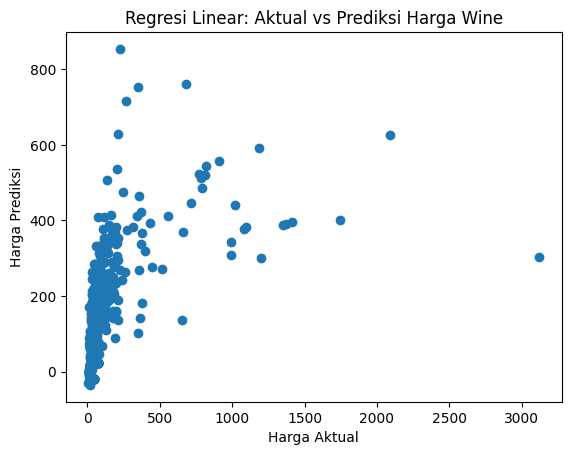

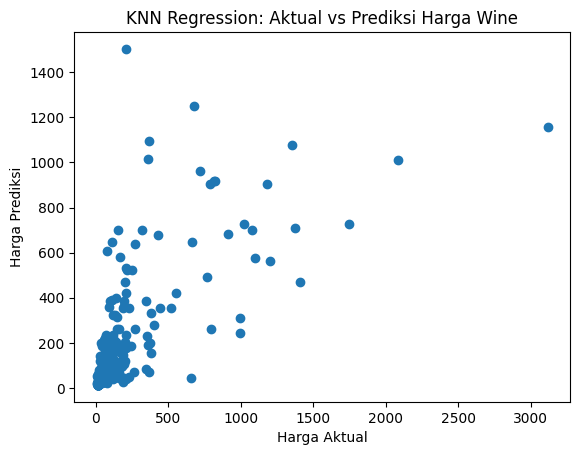


Prediksi Data Baru:
Regresi Linear : [15.74561617]
KNN Regression : [16.76]


In [3]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("wines_SPA.csv")
cols = ["year", "rating", "num_reviews", "body", "acidity", "price"]
for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=cols)
df["year"] = df["year"].astype(int)
print("Jumlah data setelah cleaning:", df.shape[0])
display(df.head())

X = df[["year", "rating", "num_reviews", "body", "acidity"]]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lr = linreg.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

hasil = pd.DataFrame({
    "Model": ["Regresi Linear", "KNN Regression"],
    "MSE": [mse_lr, mse_knn],
    "R2": [r2_lr, r2_knn]
})

print("\nTabel Evaluasi Model:")
display(hasil)

tabel_prediksi = pd.DataFrame({
    "Harga Aktual": y_test.values,
    "Prediksi Regresi Linear": y_pred_lr,
    "Prediksi KNN": y_pred_knn
})

print("\nContoh Hasil Prediksi:")
display(tabel_prediksi.head(10))

plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Regresi Linear: Aktual vs Prediksi Harga Wine")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("KNN Regression: Aktual vs Prediksi Harga Wine")
plt.show()

data_baru = pd.DataFrame({
    "year": [2018],
    "rating": [4.2],
    "num_reviews": [350],
    "body": [4.0],
    "acidity": [3.5]
})

pred_lr = linreg.predict(data_baru)
pred_knn = knn.predict(scaler.transform(data_baru))

print("\nPrediksi Data Baru:")
print("Regresi Linear :", pred_lr)
print("KNN Regression :", pred_knn)



